# 12 Objects per frame vs age (clutter proxy)

Quick check: **number of unique detected object categories per frame** (`n_objects`) as a coarse clutter proxy (more objects ⇒ busier scene).

**Important:**
- **Per frame**, `n_objects` is always a **whole number** (1, 2, 3, …).
- **Plots by age** use the **mean across frames** within each subject×month, so the y-axis is ~1.3–1.9, not integers.
- Values look **low** because most frames have only **one** distinct labeled category (~50% of frames are exactly 1; dataset mean ≈ 1.5). That is expected with `nunique(class_name)` on filtered CDI detections, not total bounding boxes.

**Model:** `mean_n_objects ~ age_mo + (age_mo | subject_id)` on subject-month means (MixedLM).

**Caveat:** CSV has **detection rows only** (no zero-object frames).

Outputs: `analysis/manuscript-2026/not_in_manuscript/clutter_proxy_exploration/`

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import mixedlm

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]
sns.set_theme(style="white", context="talk")

NOT_IN_MS_DIR = Path.cwd().resolve()
if NOT_IN_MS_DIR.name != "not_in_manuscript":
    NOT_IN_MS_DIR = NOT_IN_MS_DIR / "not_in_manuscript"
MANUSCRIPT_DIR = NOT_IN_MS_DIR.parent
PROJECT_ROOT = MANUSCRIPT_DIR.parent.parent
DATA_DIR = PROJECT_ROOT / "data"
FRAME_DATA_CSV = PROJECT_ROOT / "frame_data" / "merged_frame_detections_with_metadata_filtered-0.27.csv"

OUTPUT_RUN_ROOT = NOT_IN_MS_DIR / "clutter_proxy_exploration"
RESULTS_DIR = OUTPUT_RUN_ROOT / "results"
FIGURES_DIR = OUTPUT_RUN_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Optional: restrict to CDI-valid categories (set None to use all non-person detections)
CATEGORY_SET = "valid129"  # "valid85" | "valid129" | None
CATEGORY_FILES = {
    "valid85": DATA_DIR / "included_categories_valid85.txt",
    "valid129": DATA_DIR / "included_categories_valid129.txt",
}
ALWAYS_EXCLUDE = {"person", "picture"}

FORCE_REBUILD = False
FRAME_LEVEL_CSV = RESULTS_DIR / f"frame_level_n_objects_{CATEGORY_SET or 'all'}.csv"
SUBJECT_AGE_CSV = RESULTS_DIR / f"subject_age_month_mean_n_objects_{CATEGORY_SET or 'all'}.csv"

print(f"Frame detections: {FRAME_DATA_CSV}")
print(f"CATEGORY_SET={CATEGORY_SET!r}")
print(f"Output: {OUTPUT_RUN_ROOT}")

Frame detections: /home/j7yang/babyview-projects/vss2026/object-detection/frame_data/merged_frame_detections_with_metadata_filtered-0.27.csv
CATEGORY_SET='valid129'
Output: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/not_in_manuscript/clutter_proxy_exploration


## 1. Build frame-level table

One row per frame with `n_objects` = distinct `class_name` labels in that frame.

In [7]:
def load_included_categories(category_set: str | None) -> set[str] | None:
    if category_set is None:
        return None
    path = CATEGORY_FILES[category_set]
    return {
        line.strip().lower()
        for line in path.read_text().splitlines()
        if line.strip()
    }


def build_frame_level_table(csv_path: Path, included: set[str] | None) -> pd.DataFrame:
    usecols = ["class_name", "age_mo", "subject_id", "original_frame_path"]
    df = pd.read_csv(csv_path, usecols=usecols)
    df["class_name"] = df["class_name"].astype(str).str.strip().str.lower()
    df = df[~df["class_name"].isin(ALWAYS_EXCLUDE)].copy()
    if included is not None:
        df = df[df["class_name"].isin(included)].copy()

    frames = (
        df.groupby(["subject_id", "age_mo", "original_frame_path"], as_index=False)
        .agg(n_objects=("class_name", "nunique"))
    )
    frames["subject_id"] = frames["subject_id"].astype(str)
    return frames


included_set = load_included_categories(CATEGORY_SET)
if FRAME_LEVEL_CSV.exists() and not FORCE_REBUILD:
    frame_df = pd.read_csv(FRAME_LEVEL_CSV)
    print(f"Loaded cached frame table: {FRAME_LEVEL_CSV}")
else:
    frame_df = build_frame_level_table(FRAME_DATA_CSV, included_set)
    frame_df.to_csv(FRAME_LEVEL_CSV, index=False)
    print(f"Built and saved: {FRAME_LEVEL_CSV}")

subject_age_df = (
    frame_df.groupby(["subject_id", "age_mo"], as_index=False)
    .agg(
        mean_n_objects=("n_objects", "mean"),
        n_frames=("n_objects", "size"),
    )
)
subject_age_df.to_csv(SUBJECT_AGE_CSV, index=False)

print(f"Frames: {len(frame_df):,} | Subjects: {frame_df['subject_id'].nunique()} | Age mo: {frame_df['age_mo'].min():.0f}–{frame_df['age_mo'].max():.0f}")
print("Frame-level n_objects (integers per frame; mean across frames is fractional):")
print(frame_df["n_objects"].describe())
print(f"Fraction of frames with exactly 1 object: {(frame_df['n_objects'] == 1).mean():.1%}")
print("\nSubject-month mean_n_objects (what we plot by age):")
print(subject_age_df["mean_n_objects"].describe())

Loaded cached frame table: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/not_in_manuscript/clutter_proxy_exploration/results/frame_level_n_objects_valid129.csv
Frames: 1,532,201 | Subjects: 31 | Age mo: 6–37
Frame-level n_objects (integers per frame; mean across frames is fractional):
count    1.532201e+06
mean     1.540591e+00
std      8.386966e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.100000e+01
Name: n_objects, dtype: float64
Fraction of frames with exactly 1 object: 62.5%

Subject-month mean_n_objects (what we plot by age):
count    266.000000
mean       1.522374
std        0.180907
min        1.193578
25%        1.416221
50%        1.497295
75%        1.598090
max        2.572801
Name: mean_n_objects, dtype: float64


## 2. Exploratory plots

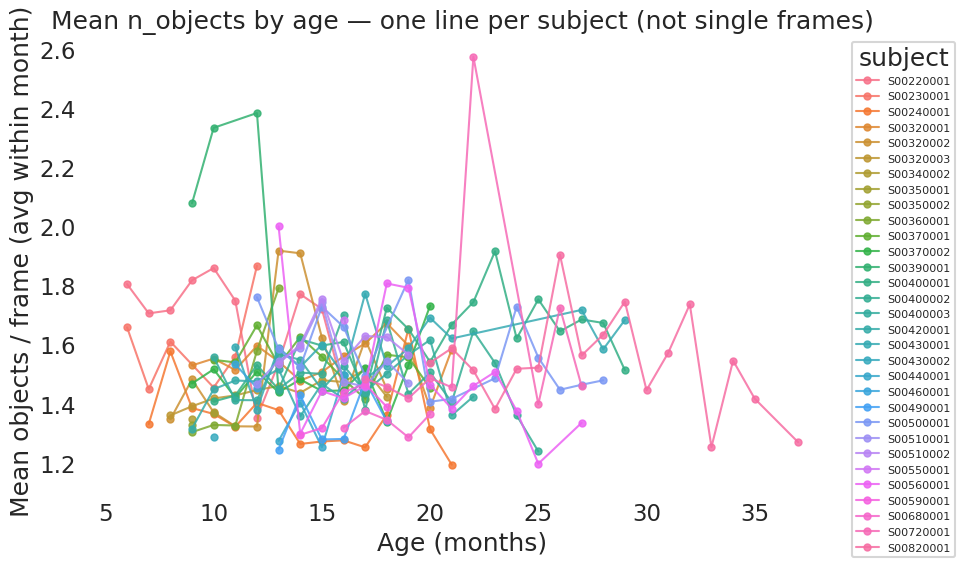

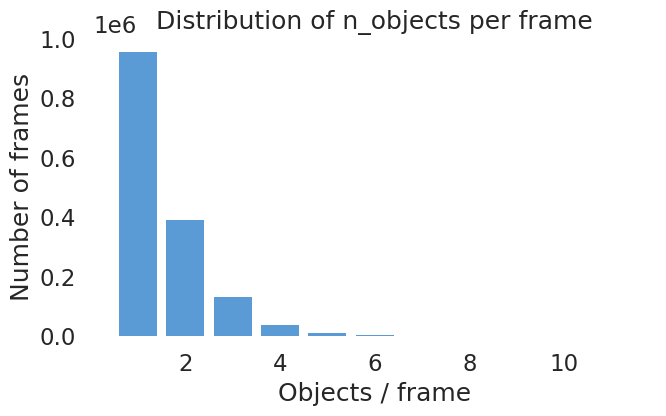

In [8]:
def _apply_axis_style(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


subjects = sorted(frame_df["subject_id"].unique())
palette = sns.color_palette("husl", n_colors=len(subjects))
subj_color = dict(zip(subjects, palette))

# A) Subject-month means: one line per kid
fig, ax = plt.subplots(figsize=(10, 6))
for sid, g in subject_age_df.groupby("subject_id"):
    g = g.sort_values("age_mo")
    ax.plot(
        g["age_mo"],
        g["mean_n_objects"],
        "o-",
        color=subj_color[sid],
        alpha=0.85,
        linewidth=1.5,
        markersize=5,
        label=sid,
    )
ax.set_xlabel("Age (months)")
ax.set_ylabel("Mean objects / frame (avg within month)")
ax.set_title("Mean n_objects by age — one line per subject (not single frames)")
_apply_axis_style(ax)
ax.legend(title="subject", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "mean_objects_per_frame_by_age_per_subject.png", dpi=150, bbox_inches="tight")
plt.show()

# B) Count distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
vc = frame_df["n_objects"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color="#5B9BD5", edgecolor="none")
ax.set_xlabel("Objects / frame")
ax.set_ylabel("Number of frames")
ax.set_title("Distribution of n_objects per frame")
_apply_axis_style(ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "n_objects_per_frame_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Model

Mixed effects on **subject-month mean** `n_objects`:

`mean_n_objects ~ age_mo + (1 + age_mo | subject_id)`

### How to read the output

- **Outcome (`mean_n_objects`):** average unique object categories per frame, aggregated within each subject×month.
- **Intercept:** predicted mean objects/frame when `age_mo = 0` (extrapolation — your youngest ages are ~6 mo; use as baseline anchor, not a literal infant-at-birth prediction).
- **`age_mo` coefficient (fixed effect):** population-average change in mean objects per **one additional month**, after accounting for per-subject random intercepts and slopes. Positive ⇒ busier scenes with age on average.
- **Random effects (`Group Var`, `Group x age_mo Cov`, `age_mo Var`):** how much kids differ in their **starting level** (intercept) and **month-to-month slope**. Large subject variance with a tiny fixed `age_mo` effect means developmental change is inconsistent across kids.
- **This is Gaussian MixedLM on means**, not a Poisson count model. Fine for a quick trend; p-values are approximate if means are skewed/discrete.

**Example (your last fit):** Intercept ≈ 1.49, `age_mo` ≈ +0.002 (p ≈ 0.67) ⇒ predicted means ~1.49 at 0 mo and ~1.51 at 12 mo — a very small, non-significant upward trend.

In [9]:
md = mixedlm(
    "mean_n_objects ~ age_mo",
    subject_age_df,
    groups=subject_age_df["subject_id"],
    re_formula="1 + age_mo",
)
res = md.fit(method="lbfgs", reml=False)
print(res.summary())

summary_path = RESULTS_DIR / "n_objects_by_age_mixedlm_summary.txt"
summary_path.write_text(res.summary().as_text())
print(f"\nSaved: {summary_path}")

            Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: mean_n_objects
No. Observations:  266     Method:             ML            
No. Groups:        31      Scale:              0.0217        
Min. group size:   1       Log-Likelihood:     102.5183      
Max. group size:   20      Converged:          Yes           
Mean group size:   8.6                                       
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           1.490    0.068 22.022 0.000  1.357  1.623
age_mo              0.002    0.004  0.429 0.668 -0.006  0.009
Group Var           0.082    0.264                           
Group x age_mo Cov -0.004    0.014                           
age_mo Var          0.000    0.001                           


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscri

/data/j7yang/anaconda3/envs/vislearnlabpy/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 4. Pooled age trend

Spearman(age, mean objects/frame): rho=0.091, p=0.137


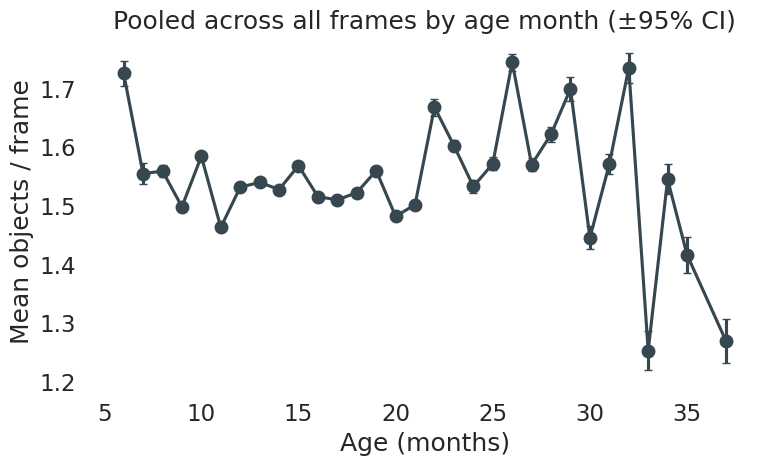

In [10]:
rho, p = stats.spearmanr(subject_age_df["age_mo"], subject_age_df["mean_n_objects"])
print(f"Spearman(age, mean objects/frame): rho={rho:.3f}, p={p:.3g}")

age_pooled = (
    frame_df.groupby("age_mo", as_index=False)
    .agg(mean_n=("n_objects", "mean"), se=("n_objects", lambda x: x.std() / np.sqrt(len(x))))
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    age_pooled["age_mo"],
    age_pooled["mean_n"],
    yerr=1.96 * age_pooled["se"],
    fmt="o-",
    color="#37474f",
    capsize=3,
)
ax.set_xlabel("Age (months)")
ax.set_ylabel("Mean objects / frame")
ax.set_title("Pooled across all frames by age month (±95% CI)")
_apply_axis_style(ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pooled_mean_objects_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Optional extensions

- Frame-level Poisson / negative-binomial GLMM in R (`lme4::glmer.nb`) if you want count-family inference.
- Clutter **bouts** (run lengths of low vs high `n_objects` within videos).
- **Semantic diversity** per frame (unique CDI domains, not just object count).